In [81]:
import numpy as np
import random
from collections import defaultdict
from typing import Callable, List, Set
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#### Monte-Carlo Simulation for Max-Expectancy Nth Coupon Problem
Goal: Find which packet distribution (law) maximizes $\mathbb{E}[T]$ subject to fairness condition

In [127]:
# Fix parameters
S = 500  # coupons per packet
N = 1000  # total unique coupons
N_TRIALS = 5000

def sim_collection(packet_sampler: Callable[[], Set[int]], n: int = N) -> int:
  # Simulate one run.
  # Returns the number of packets drawn to collect all n coupons.

  collection = set()
  draws = 0
  while len(collection) < n:
    packet = packet_sampler()
    collection.update(packet)
    draws += 1
  return draws


#### --- Distribution Samplers (Laws) ---
Functions in which satisfy certain laws we will be simulating with.

**Uniform Distribution:**: Uniform over all $C(n, s)$ subsets.

Ex: Drawable subsets: $C(12,3) = \binom{12}{3} = \frac{12!}{3!(12 - 3)!} = \frac{12 \cdot 11 \cdot 10}{3 \cdot 2 \cdot 1} = 220$  distinct packets. 

Sample 4 trials: $[0, 1, 8], [0, 4, 9], [1, 2, 8], [0, 1, 9]$ with $216$ unique packets left

Collection = $[0, 1, 2, 4, 8, 9]$

**Partition Distribution**: Partition coupons into disjoint groups of size s. Sample uniformly among these groups and require $s|n$. 

Ex: Drawable subsets for $n = 6, s = 2$: $[0,1], [2,3], [4,5]$

Sample 4 trials: $[0,1], [0,1], [4, 5], [0,1], [0,1]$

Collection = [0, 1]

**Double Partition Distribution**: Create two different partitions of coupons into groups of size $s$. 
At each draw: 
* Choose a partition uniformly at random $(50/50)$
* Choose a group uniformly from that parition

parition_style options: 
* "consecutive_stride": P1 = consecutive blocks, P2 = strided blocks
* "random_orthogonal": P1 = consecutive, P2 = randomly shuffled (attempt at orthogonality)

Requires $s|n$.

In [128]:
def uniform_sampler(n: int = N, s: int = S) -> Callable[[], Set[int]]:
  def sample():
    return set(random.sample(range(n), s))
  return sample

In [129]:
def partition_sampler(n: int = N, s: int = S) -> Callable[[], Set[int]]:
  assert n % s == 0
  groups = [set(range(i*s, (i+1)*s)) for i in range(n//s)]
  def sample():
    return random.choice(groups).copy()
  return sample

In [130]:
def double_partition_sampler(n: int = N, s: int = S, partition_style: str = "consecutive_stride") -> Callable[[], Set[int]]:
  assert n % s == 0
  num_groups = n // s

  # Partition 1: Consecutive blocks [0, 1, 2], [3, 4, 5], ...
  p1_groups = [set(range(i*s, (i+1)*s)) for i in range(num_groups)]

  # Parition 2: Depends on specfic style
  if partition_style == "consecutive_stride":
    # Stride by num_groups: [0, 4, 8], [1, 5, 9], ... for n = 100, s = 5, stride =100/5 = 20
    p2_groups = [set(range(start, n, num_groups)) for start in range(num_groups)]
  
  elif partition_style == "random_orthogonal":
    # Create a random permutation and chunk it
    # Note: this does NOT guarantee orthonality, but adds randomness
    rng = random.Random(42)
    perm = list(range(n))
    rng.shuffle(perm)
    p2_groups = [set(perm[i*s:(i+1)*s]) for i in range(num_groups)]

  else: raise ValueError(f"Unknown partition_style: {partition_style}")

  def sample():
    if(random.random() < 0.5):
      return random.choice(p1_groups).copy()
    else: return random.choice(p2_groups).copy()
  return sample

In [131]:
def triple_partition_sampler(n: int = N, s: int = S, partition_style: str = "consecutive_stride") -> Callable[[], Set[int]]:
  assert n % s == 0
  num_groups = n // s

  
  # Partition 1: Consecutive blocks [0, 1, 2], [3, 4, 5], ...
  p1_groups = [set(range(i*s, (i+1*s)) for i in range(num_groups))]


  # Parition 2: Depends on specfic style
  if partition_style == "consecutive_stride":
    # Stride by num_groups: [0, 4, 8], [1, 5, 9], ... for n = 100, s = 5, stride =100/5 = 20
    p2_groups = [set(range(start, n, num_groups)) for start in range(num_groups)]
  
  elif partition_style == "random_orthogonal":
    # Create a random permutation and chunk it
    # Note: this does NOT guarantee orthonality, but adds randomness
    rng = random.Random(42)
    perm = list(range(n))
    rng.shuffle(perm)
    p2_groups = [set(perm[i*s:(i+1)*s]) for i in range(num_groups)]

  rng = random.Random(124)
  perm = list(range(n))
  rng.shuffle(perm)
  p3_groups = [set(perm[i*s:(i+1)*s]) for i in range(num_groups)]

  def sample():
    choice = random.random()

    if choice < 0.33:
      return random.choice(p1_groups).copy()
    elif choice < 0.66:
      return random.choice(p2_groups).copy()
    else:
      return random.choice(p3_groups).copy()
  return sample

In [132]:
def run_sim(sampler_func: Callable[[], Set[int]], name: str, n_trials: int = N_TRIALS):
  # Run Monte-Carlo for one distribution and report results.
  start = time.time()  # Track starting time of simulation.
  results = [sim_collection(sampler_func) for _ in range(n_trials)]
  elapsed = time.time() - start

  expectancy_t = np.mean(results)
  std_t = np.std(results)
  median_t = np.median(results)

  print(f"\n{name:30s} | "
        f"E[T] = {expectancy_t:6.3f} ± {std_t/np.sqrt(n_trials):.3f} | "
        f"std = {std_t:6.3f} | "
        f"median = {median_t:5.1f} | "
        f"time: {elapsed:.2f}s")
  
  return results

In [133]:
def display_results(results_dict: dict, save_path: str = "results_plot.png"):
  # Plots histograms and comparison plots for simulation results.
  # Arguments: 
  #       results_dict: {distribution_name: list_of_T_values}
  #       save_path: where to save the figure

  # Set style
  sns.set_style("whitegrid")
  sns.set_context("notebook", font_scale=1.1)

  # === PLOT 1: Overlaid Histogram Comparison w/ KDE ===
  plt.figure(figsize=(12, 6))

  for name, values in results_dict.items():
    sns.histplot(values, kde=True, label=name, alpha=0.4, bins=30)
  
  plt.xlabel("Collection Time T (packets drawn)", fontsize = 12)
  plt.ylabel("Frequency", fontsize = 12)
  plt.title("Distribution of Collection Times by Packet Law", fontsize = 14, fontweight = 'bold')
  plt.legend(title="Distribution")
  plt.tight_layout()
  plt.savefig(save_path.replace(".png", "_hist.png"), dpi=300, bbox_inches="tight")
  plt.show()


  # # === PLOT 2: Box Plot Comparison ===
  # plt.figure(figsize = (10,6))

  # plot_data = []
  # labels = []
  # for name, values in results_dict.items():
  #   plot_data.extend(values)
  #   labels.extend([name] * len(values))
  
  # df = pd.DataFrame({'T': plot_data, 'Distribution': labels})

  # sns.boxplot(data=df, x='Distribution', y='T', palette="Set2")
  # plt.xlabel("Packet Distribution Law", fontsize=12)
  # plt.ylabel("Collection Time T", fontsize=12)
  # plt.xticks(rotation=45, ha='right')
  # plt.tight_layout()
  # plt.savefig(save_path.replace(".png", "_box_.png"), dpi=300, bbox_inches="tight")
  # plt.show()

  # # === PLOT 3: Summary Statistic Bar Chart ===
  # plt.figure(figsize = (10, 6))
  
  # expectancys = [np.mean(v) for v in results_dict.values()]
  # stds = [np.std(v) for v in results_dict.values()]
  # names = list(results_dict.keys())

  # x_pos = np.arange(len(names))
  # plt.bar(x_pos, expectancys, yerr=stds, capsize=5)
  # plt.xticks(x_pos, names, rotation=45, ha='right')
  # plt.xlabel("Packet Distribution Law", fontsize=12)
  # plt.ylabel("Expectancy Collection Time $\\mathbb{E}[T]$", fontsize=12)
  # plt.title("Mean Collection Time ± Standard Deviation", fontsize=14, fontweight='bold')
  # plt.axhline(y=np.mean(expectancys), color='gray', linestyle='--', alpha=0.5, label='Overall Expectancy')
  # plt.legend()
  # plt.tight_layout()
  # plt.savefig(save_path.replace(".png", "_bar.png"), dpi=300, bbox_inches='tight')
  # plt.show()

  
  # # === PLOT 4: Empirical Cumulative Distribution ===
  # plt.figure(figsize=(10, 6))

  # for name, values in results_dict.items():
  #   sorted_vals = np.sort(values)
  #   cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
  #   plt.plot(sorted_vals, cdf, label=name, linewidth=2)
  
  # plt.xlabel("Collection Time T", fontsize=12)
  # plt.ylabel("Cumulative Probability $P(T <= t)$", fontsize=12)
  # plt.title("Empirical CDF of Collection Times", fontsize = 14, fontweight='bold')
  # plt.legend()
  # plt.grid(alpha=0.3)
  # plt.tight_layout()
  # plt.savefig(save_path.replace(".png", "_cdf.png"), dpi=300, bbox_inches='tight')
  # plt.show()

Max-Expectancy Coupon Simulation | n=1000, s=500, trials=5000

Uniform                        | E[T] = 11.291 ± 0.026 | std =  1.825 | median =  11.0 | time: 8.23s

Partition                      | E[T] =  3.025 ± 0.020 | std =  1.419 | median =   3.0 | time: 0.08s

Double Partition               | E[T] =  3.652 ± 0.023 | std =  1.612 | median =   3.0 | time: 0.12s

Triple Partition               | E[T] =  5.458 ± 0.042 | std =  2.964 | median =   5.0 | time: 0.19s

Generating plots...


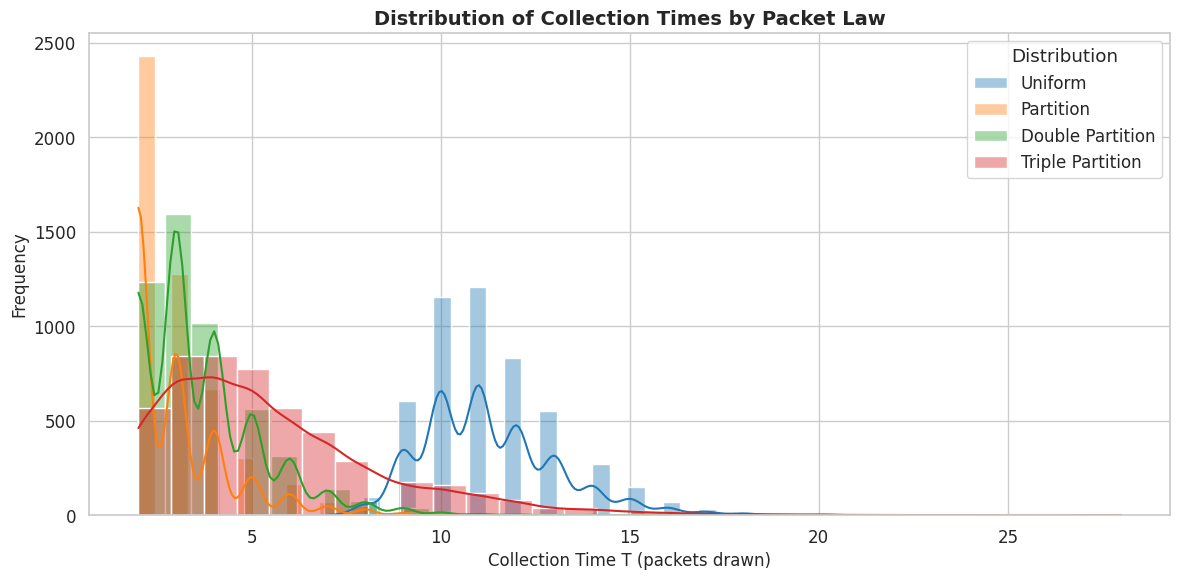


RANKING BY E[T] (Highest = Hardest):
1. Uniform                   | E[T] = 11.291
2. Triple Partition          | E[T] = 5.458
3. Double Partition          | E[T] = 3.652
4. Partition                 | E[T] = 3.025


In [134]:
def main():
  print(f"Max-Expectancy Coupon Simulation | n={N}, s={S}, trials={N_TRIALS}")
  print("="*100)

  distributions = {
    "Uniform": uniform_sampler(),
    "Partition": partition_sampler(),
    "Double Partition": double_partition_sampler(), 
    "Triple Partition": triple_partition_sampler(),
  }

  results_dict = {}  # Raw results

  for name, sampler in distributions.items():
    results_dict[name] = run_sim(sampler, name)  

  # Generate plots
  print("\nGenerating plots...")
  display_results(results_dict, save_path="coupon_sim_results.png")

  print("\n" + "="*80)
  print("RANKING BY E[T] (Highest = Hardest):")
  ranked = sorted([(k, np.mean(v)) for k,v in results_dict.items()], 
                  key = lambda x: x[1], reverse=True)
  for rank, (name, expectancy_t) in enumerate(ranked, 1):
    print(f"{rank}. {name:25s} | E[T] = {expectancy_t:.3f}")

if __name__ == "__main__":
  # Set seed for reproducibility 
  random.seed(42)
  np.random.seed(42)
  main()  